In this notebook, I will analyse and answer:

#### “Given the demand patterns and shipping behavior, how should inventory be managed efficiently?”

This includes:

- deciding warehouse replenishment 
- preventing stockouts
- reducing storage cost
- which products are high-risk
- optimising inventory levels to align with operations and meet customer service

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as ticker

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/raw/amazon_ecommerce_1M.csv")

In [4]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

df['revenue'] = df['final_price']

df['return_flag'] = df['is_returned'].astype(int)

Since this dataset does not have inventory movement data.

- I define demand as: number of purchases per category per day

In [5]:
category_demand = (
    df.groupby(['purchase_date', 'category'])
    .size()
    .reset_index(name='demand')
)

In [6]:
category_demand.head(10)

,purchase_date,category,demand
0,2024-03-31,Beauty,293
1,2024-03-31,Clothing,273
2,2024-03-31,Electronics,272
3,2024-03-31,Home,292
4,2024-03-31,Sports,270
5,2024-04-01,Beauty,271
6,2024-04-01,Clothing,268
7,2024-04-01,Electronics,276
8,2024-04-01,Home,283
9,2024-04-01,Sports,282


### LEAD TIME Concept

- time it takes for inventory to be replenished and arrive at the customer

In [7]:
lead_time = df['shipping_time_days']

In [8]:
avg_lead_time = df['shipping_time_days'].mean()

print(f"Average Lead Time: {avg_lead_time:.2f} days")

Average Lead Time: 3.17 days


### SAFETY STOCK 

- Safety stock is extra inventory kept to prevent stockouts due to uncertainty

In [9]:
demand_std = category_demand.groupby('category')['demand'].std()

Calculating Safety Stock

- Z = service level factor (we assume 1.65 for ~95%)
- σd = demand standard deviation
- L = lead time

In [10]:
Z = 1.65

lead_time = df['shipping_time_days'].mean()

safety_stock = Z * demand_std * np.sqrt(lead_time)

safety_stock = safety_stock.reset_index()
safety_stock.columns = ['category', 'safety_stock']

Categories with:

- high volatility → need more safety stock
- stable demand → need less safety stock

In [11]:
safety_stock.head(10)

,category,safety_stock
0,Beauty,46.700234
1,Clothing,47.603337
2,Electronics,49.713824
3,Home,46.893111
4,Sports,48.235290


### ROP- Reorder Points
Reorder Point is the inventory level at which you reorder stock.

- ROP=(Average Daily Demand×Lead Time)+Safety Stock
- If inventory drops below ROP: reorder immediately

In [12]:
avg_daily_demand = category_demand.groupby('category')['demand'].mean()

rop = pd.DataFrame({
    'category': avg_daily_demand.index,
    'avg_demand': avg_daily_demand.values,
    'safety_stock': safety_stock['safety_stock'].values
})

rop['reorder_point'] = (
    rop['avg_demand'] * lead_time
) + rop['safety_stock']

In [18]:
rop.head()

,category,avg_demand,safety_stock,reorder_point
0,Beauty,272.677155,46.700234,910.102177
1,Clothing,273.357045,47.603337,913.158078
2,Electronics,273.649795,49.713824,916.195524
3,Home,274.859097,46.893111,917.203933
4,Sports,273.445964,48.235290,914.071584


### EOQ (ECONOMIC ORDER QUANTITY)

EOQ determines optimal order quantity that minimizes total cost. Balancing ordering cost and holding cost

We assume:

In [13]:
D = category_demand.groupby('category')['demand'].sum()

S = 50   # ordering cost assumption
H = 5    # holding cost assumption

- high EOQ → large batch ordering
- low EOQ → frequent small orders

In [14]:
eoq = np.sqrt((2 * D * S) / H)

eoq = eoq.reset_index()
eoq.columns = ['category', 'EOQ']

In [20]:
eoq.head()

,category,EOQ
0,Beauty,1996.632164
1,Clothing,1999.119806
2,Electronics,2000.189991
3,Home,2004.604699
4,Sports,1999.444923


### INVENTORY RISK SCORING

In [15]:
df['inventory_risk_score'] = np.where(
    df['stock'] < 50, 2,
    np.where(df['stock'] < 100, 1, 0)
)

Category Risk Analysis

In [16]:
risk_by_category = df.groupby('category')['inventory_risk_score'].mean()

risk_by_category.sort_values(ascending=False)

category
Home           0.300684
Clothing       0.300299
Beauty         0.298755
Sports         0.298501
Electronics    0.297548
Name: inventory_risk_score, dtype: float64

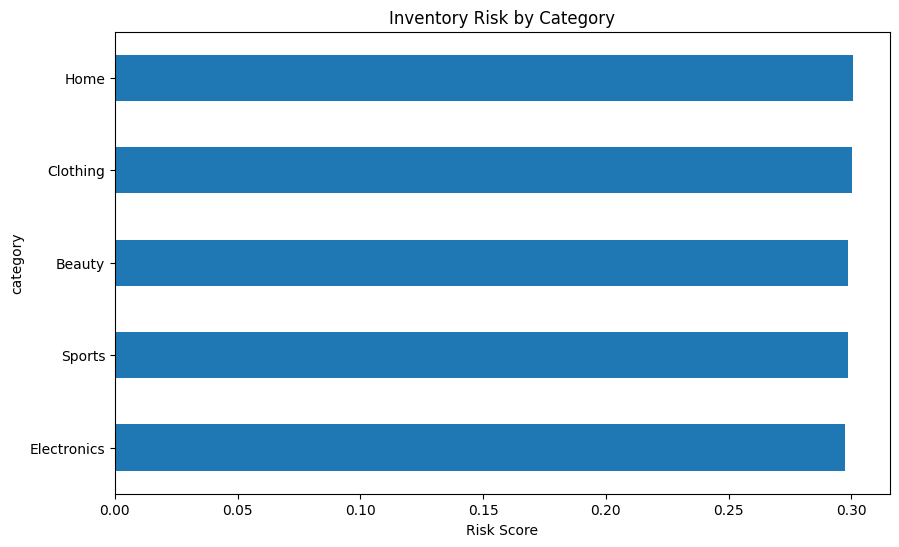

In [17]:
plt.figure(figsize=(10,6))

risk_by_category.sort_values().plot(kind='barh')

plt.title('Inventory Risk by Category')
plt.xlabel('Risk Score')

plt.show()

## Inventory Optimization Insights

### Key Findings

- High-demand categories require higher safety stock buffers.
- Variability in demand increases inventory risk exposure.
- Certain categories have consistently higher reorder points.
- EOQ analysis suggests optimal batch ordering strategies differ across categories.

### Operational Impact

- Poor inventory planning increases stockouts and lost sales.
- Excess inventory increases storage and holding costs.
- Proper reorder point planning improves supply chain reliability.

### Recommendations

- Implement category-based inventory strategies.
- Increase safety stock for volatile demand categories.
- Align procurement with EOQ calculations.
- Monitor high-risk categories closely.